In [4]:
import pandas as pd

# Load Shiller's dataset from local file (old .xls format requires xlrd engine)
df_raw = pd.read_excel("ie_data.xls", sheet_name="Data", header=7, engine="xlrd")

# Preview the first rows and column names to understand the structure
print(df_raw.head(10))
print("\nColumn names:", df_raw.columns.tolist())
print("\nShape:", df_raw.shape)

      Date     P     D    E        CPI     Fraction Rate GS10       Price  \
0  1871.01  4.44  0.26  0.4  12.464061  1871.041667      5.32  109.050018   
1  1871.02   4.5  0.26  0.4  12.844641  1871.125000  5.323333  107.248908   
2  1871.03  4.61  0.26  0.4  13.034972  1871.208333  5.326667  108.266269   
3  1871.04  4.74  0.26  0.4  12.559226  1871.291667      5.33  115.536124   
4  1871.05  4.86  0.26  0.4  12.273812  1871.375000  5.333333  121.215781   
5  1871.06  4.82  0.26  0.4  12.083481  1871.458333  5.336667  122.111712   
6  1871.07  4.73  0.26  0.4  12.083481  1871.541667      5.34  119.831618   
7  1871.08  4.79  0.26  0.4  11.893231  1871.625000  5.343333  123.292878   
8  1871.09  4.84  0.26  0.4  12.178646  1871.708333  5.346667  121.660246   
9  1871.10  4.59  0.26  0.4  12.368896  1871.791667      5.35  113.601508   

   Dividend     Price.1  ...  CAPE  Unnamed: 13  TR CAPE  Unnamed: 15  Yield  \
0  6.385812  109.050018  ...   NaN          NaN      NaN          NaN   

In [5]:
import pandas as pd

# Load Shiller's dataset from local file
df_raw = pd.read_excel("ie_data.xls", sheet_name="Data", header=7)

# Keep only the columns we need: date, price and CAPE ratio
df = df_raw[["Date", "P", "CAPE"]].copy()

# Rename columns to something clearer
df.columns = ["date", "price", "cape"]

# Remove rows where date or CAPE is missing
df = df.dropna(subset=["date", "cape"])

# Convert date from decimal format (e.g. 1871.01) to proper datetime
# The decimal represents year + month/100, so 1871.01 = January 1871
df["date"] = pd.to_datetime(df["date"].astype(str).str[:7], format="%Y.%m")

# Reset index after dropping rows
df = df.reset_index(drop=True)

# Preview cleaned data
print(df.head(10))
print("\nShape:", df.shape)
print("\nDate range:", df["date"].min(), "to", df["date"].max())

        date price       cape
0 1881-01-01  6.19  18.473952
1 1881-02-01  6.17  18.147258
2 1881-03-01  6.24  18.270119
3 1881-04-01  6.22  17.950108
4 1881-05-01   6.5  18.869719
5 1881-06-01  6.58  19.028711
6 1881-07-01  6.35  18.116367
7 1881-08-01   6.2  17.286244
8 1881-09-01  6.25  16.724837
9 1881-01-01  6.15  16.261989

Shape: (1713, 3)

Date range: 1881-01-01 00:00:00 to 2023-09-01 00:00:00


In [6]:
# Save cleaned data to CSV for later use
df.to_csv("shiller_cape_clean.csv", index=False)

print("File saved: shiller_cape_clean.csv")

File saved: shiller_cape_clean.csv


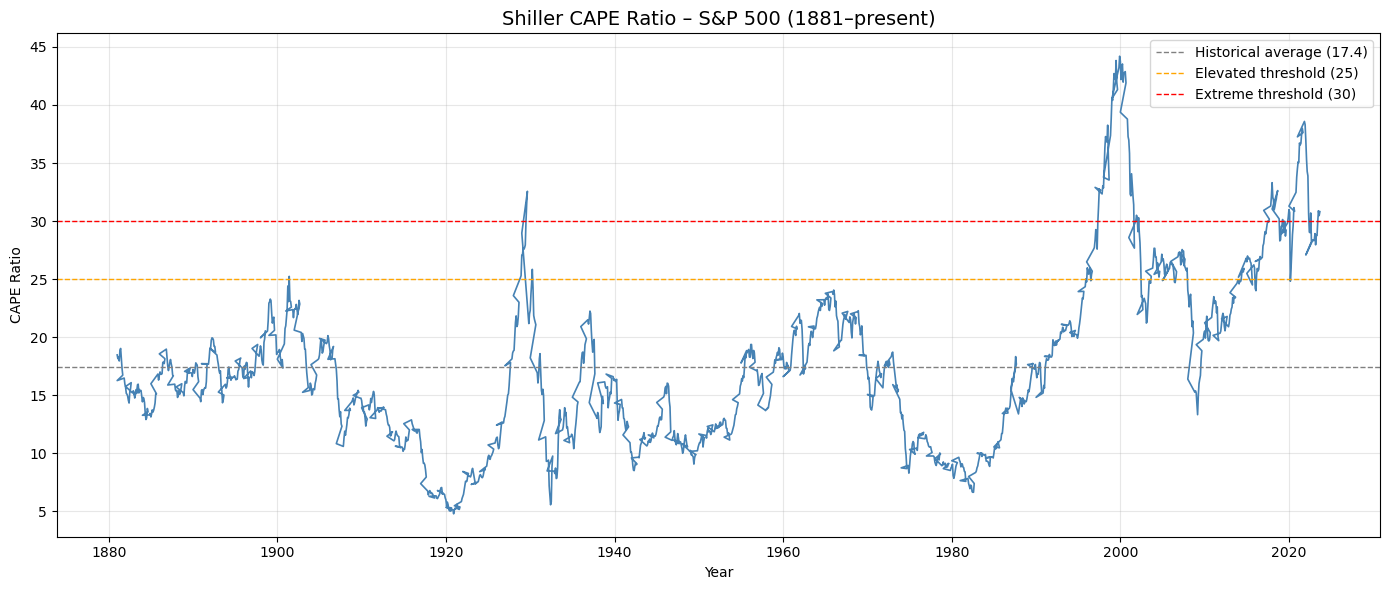

Chart saved: cape_over_time.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Plot CAPE ratio over time
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df["date"], df["cape"], color="steelblue", linewidth=1.2)

# Add horizontal lines for historical average and key thresholds
ax.axhline(df["cape"].mean(), color="gray", linestyle="--", linewidth=1, label=f"Historical average ({df['cape'].mean():.1f})")
ax.axhline(25, color="orange", linestyle="--", linewidth=1, label="Elevated threshold (25)")
ax.axhline(30, color="red", linestyle="--", linewidth=1, label="Extreme threshold (30)")

# Labels and formatting
ax.set_title("Shiller CAPE Ratio – S&P 500 (1881–present)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("CAPE Ratio")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save chart as PNG for article and dashboard
plt.savefig("cape_over_time.png", dpi=150)
plt.show()

print("Chart saved: cape_over_time.png")

In [8]:
# Calculate future 10-year annualized return for each row
# We shift the price column 120 months (10 years) back to get the future price
df["price_future"] = df["price"].shift(-120)

# Annualized return formula: (future_price / current_price) ^ (1/10) - 1
df["return_10y"] = (df["price_future"] / df["price"]) ** (1 / 10) - 1

# Drop rows where we don't have a future price yet (last 10 years)
df_model = df.dropna(subset=["return_10y", "cape"]).copy()

print(df_model[["date", "cape", "return_10y"]].head(10))
print("\nShape:", df_model.shape)

        date       cape return_10y
0 1881-01-01  18.473952  -0.024302
1 1881-02-01  18.147258  -0.022783
2 1881-03-01  18.270119  -0.025692
3 1881-04-01  17.950108  -0.022185
4 1881-05-01  18.869719  -0.026874
5 1881-06-01  19.028711  -0.030045
6 1881-07-01  18.116367  -0.028205
7 1881-08-01  17.286244   -0.02266
8 1881-09-01  16.724837  -0.015797
9 1881-01-01  16.261989  -0.014208

Shape: (1593, 5)


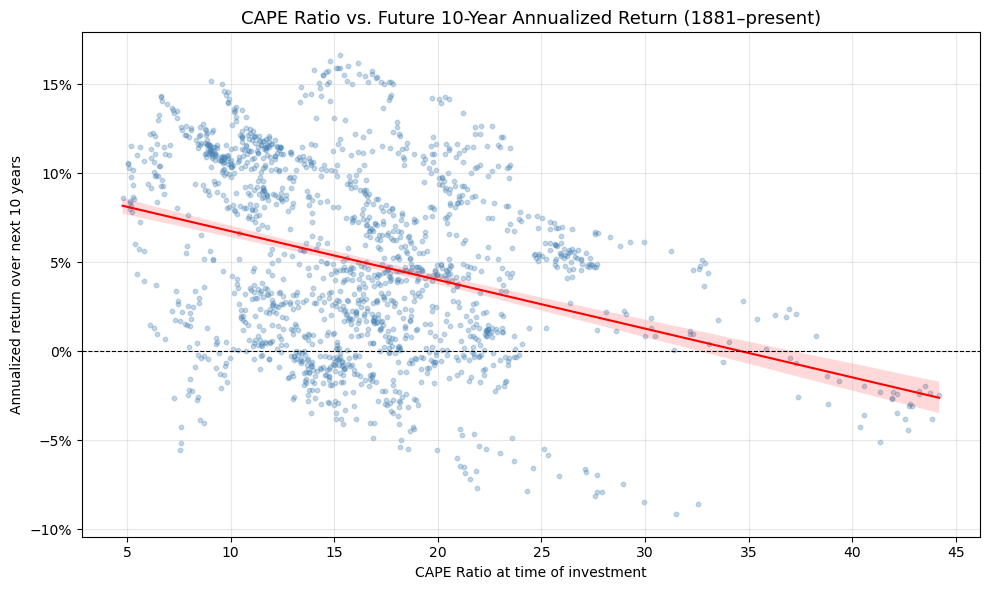

Chart saved: cape_vs_return.png


In [12]:
import seaborn as sns

# Ensure columns are proper float values before plotting
df_model["cape"] = pd.to_numeric(df_model["cape"], errors="coerce")
df_model["return_10y"] = pd.to_numeric(df_model["return_10y"], errors="coerce")
df_model = df_model.dropna(subset=["cape", "return_10y"])

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot: CAPE on x-axis, future 10y return on y-axis
ax.scatter(df_model["cape"], df_model["return_10y"], alpha=0.3, s=10, color="steelblue")

# Add a regression line to show the trend
sns.regplot(data=df_model, x="cape", y="return_10y", scatter=False,
            color="red", line_kws={"linewidth": 1.5}, ax=ax)

# Format y-axis as percentage
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))

# Labels and formatting
ax.set_title("CAPE Ratio vs. Future 10-Year Annualized Return (1881–present)", fontsize=13)
ax.set_xlabel("CAPE Ratio at time of investment")
ax.set_ylabel("Annualized return over next 10 years")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save chart
plt.savefig("cape_vs_return.png", dpi=150)
plt.show()

print("Chart saved: cape_vs_return.png")

In [10]:
# Ensure columns are proper float values
df_model["cape"] = pd.to_numeric(df_model["cape"], errors="coerce")
df_model["return_10y"] = pd.to_numeric(df_model["return_10y"], errors="coerce")
df_model = df_model.dropna(subset=["cape", "return_10y"])

from scipy import stats

# Calculate Pearson correlation between CAPE and future 10-year return
corr, pvalue = stats.pearsonr(df_model["cape"], df_model["return_10y"])

# Run a simple linear regression to get R-squared
slope, intercept, r_value, p_value, std_err = stats.linregress(df_model["cape"], df_model["return_10y"])

print(f"Pearson correlation: {corr:.3f}")
print(f"R-squared:           {r_value**2:.3f}")
print(f"P-value:             {p_value:.6f}")
print(f"Slope:               {slope:.6f}")

Pearson correlation: -0.344
R-squared:           0.118
P-value:             0.000000
Slope:               -0.002738


In [ ]:
# Save regression results to CSV
results = pd.DataFrame({
    "metric": ["pearson_correlation", "r_squared", "p_value", "slope"],
    "value": [corr, r_value**2, p_value, slope]
})

results.to_csv("cape_regression_results.csv", index=False)
print("File saved: cape_regression_results.csv")

In [11]:
import yfinance as yf

# Download Shiller CAPE ratio from Yahoo Finance
cape_today = yf.download("CAPE", period="1mo")["Close"].dropna().iloc[-1].item()

print(f"Current CAPE ratio: {cape_today:.2f}")

/var/folders/yr/pn5133x93hj8g567bcn3hfw40000gn/T/ipykernel_17146/2423352890.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  cape_today = yf.download("CAPE", period="1mo")["Close"].dropna().iloc[-1].item()
[*********************100%***********************]  1 of 1 completed

Current CAPE ratio: 33.07


In [12]:
# Use the regression formula to estimate future 10-year annualized return
# Formula: return = intercept + slope * cape_today
predicted_return = intercept + slope * cape_today

print(f"Current CAPE:              {cape_today:.2f}")
print(f"Historical average CAPE:   {df_model['cape'].mean():.2f}")
print(f"Predicted 10-year return:  {predicted_return:.2%} per year")

Current CAPE:              33.07
Historical average CAPE:   16.50
Predicted 10-year return:  0.42% per year


In [13]:
# Save final prediction to CSV
prediction = pd.DataFrame({
    "metric": ["cape_today", "historical_avg_cape", "predicted_10y_return"],
    "value": [cape_today, df_model["cape"].mean(), predicted_return]
})

prediction.to_csv("cape_prediction.csv", index=False)
print("File saved: cape_prediction.csv")

File saved: cape_prediction.csv


In [ ]:
#quintile analysis

In [14]:
# Divide CAPE into 5 equal groups (quintiles)
df_model["cape_quintile"] = pd.qcut(df_model["cape"], q=5, labels=["Very Low", "Low", "Medium", "High", "Very High"])

# Calculate average 10-year return per quintile
quintile_summary = df_model.groupby("cape_quintile", observed=True)["return_10y"].agg(
    avg_return="mean",
    median_return="median",
    count="count"
).reset_index()

# Convert returns to percentage for readability
quintile_summary["avg_return_pct"] = quintile_summary["avg_return"] * 100
quintile_summary["median_return_pct"] = quintile_summary["median_return"] * 100

print(quintile_summary[["cape_quintile", "avg_return_pct", "median_return_pct", "count"]])

  cape_quintile  avg_return_pct  median_return_pct  count
0      Very Low        8.110221          10.207484    319
1           Low        5.500017           5.091053    318
2        Medium        4.147507           2.914367    319
3          High        4.313910           4.311128    318
4     Very High        2.732200           2.699206    319


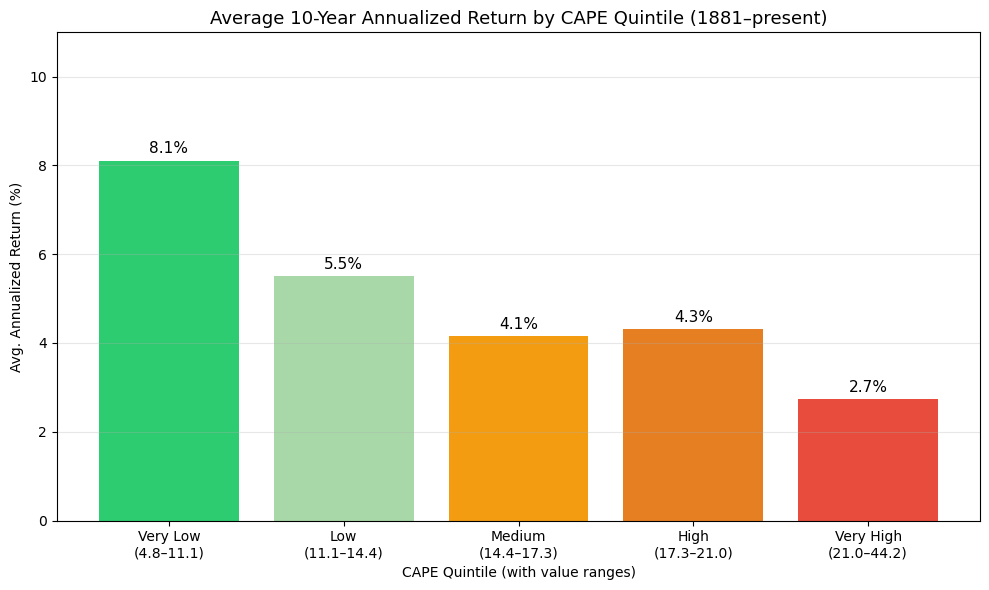

Chart saved: cape_quintile_returns.png


In [17]:
# Define quintile labels with CAPE ranges
quintile_labels = [
    "Very Low\n(4.8–11.1)",
    "Low\n(11.1–14.4)",
    "Medium\n(14.4–17.3)",
    "High\n(17.3–21.0)",
    "Very High\n(21.0–44.2)"
]

fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart: average 10-year return per CAPE quintile
bars = ax.bar(quintile_labels, quintile_summary["avg_return_pct"],
              color=["#2ecc71", "#a8d8a8", "#f39c12", "#e67e22", "#e74c3c"])

# Add value labels on top of each bar
for bar, val in zip(bars, quintile_summary["avg_return_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=11)

# Labels and formatting
ax.set_title("Average 10-Year Annualized Return by CAPE Quintile (1881–present)", fontsize=13)
ax.set_xlabel("CAPE Quintile (with value ranges)")
ax.set_ylabel("Avg. Annualized Return (%)")
ax.set_ylim(0, 11)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()

# Save chart
plt.savefig("cape_quintile_returns.png", dpi=150)
plt.show()

print("Chart saved: cape_quintile_returns.png")

In [18]:
# Calculate future returns for 1, 5 and 10 years
df_model["return_1y"] = (df["price"].shift(-12) / df["price"]) ** (1 / 1) - 1
df_model["return_5y"] = (df["price"].shift(-60) / df["price"]) ** (1 / 5) - 1
df_model["return_10y"] = (df["price"].shift(-120) / df["price"]) ** (1 / 10) - 1

# Ensure float values
for col in ["return_1y", "return_5y", "return_10y"]:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Calculate correlation between CAPE and each return horizon
from scipy import stats

for horizon, col in [("1-Year", "return_1y"), ("5-Year", "return_5y"), ("10-Year", "return_10y")]:
    df_temp = df_model[["cape", col]].dropna()
    corr, pval = stats.pearsonr(df_temp["cape"], df_temp[col])
    print(f"{horizon} correlation with CAPE: {corr:.3f}  (p-value: {pval:.6f})")

1-Year correlation with CAPE: -0.178  (p-value: 0.000000)
5-Year correlation with CAPE: -0.348  (p-value: 0.000000)
10-Year correlation with CAPE: -0.344  (p-value: 0.000000)


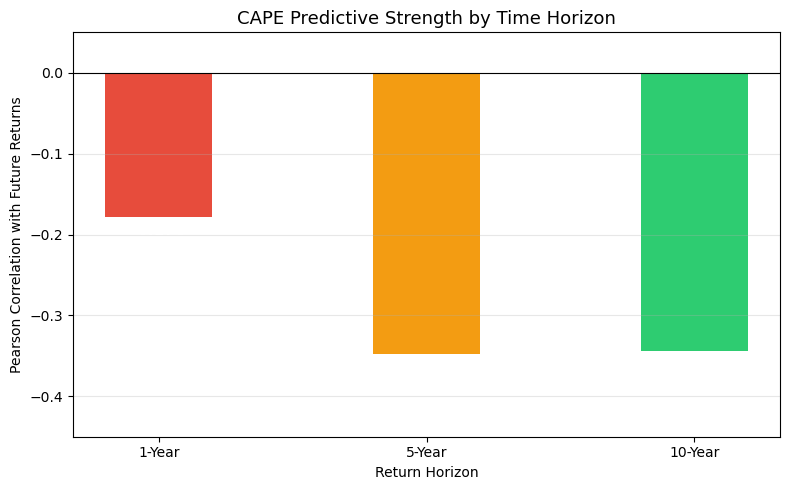

Chart saved: cape_correlation_by_horizon.png


In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

# Bar chart: correlation per time horizon
bars = ax.bar(horizons, correlations,
              color=["#e74c3c", "#f39c12", "#2ecc71"],
              width=0.4)

# Add value labels on each bar
for bar, val in zip(bars, correlations):
    ax.text(bar.get_x() + bar.get_width() / 2, val - 0.008,
            f"{val:.3f}", ha="center", va="top", fontsize=11, fontweight="bold", color="white")

# Labels and formatting
ax.set_title("CAPE Predictive Strength by Time Horizon", fontsize=13)
ax.set_xlabel("Return Horizon")
ax.set_ylabel("Pearson Correlation with Future Returns")
ax.set_ylim(-0.45, 0.05)
ax.axhline(0, color="black", linewidth=0.8)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()

# Save chart
plt.savefig("cape_correlation_by_horizon.png", dpi=150)
plt.show()

print("Chart saved: cape_correlation_by_horizon.png")

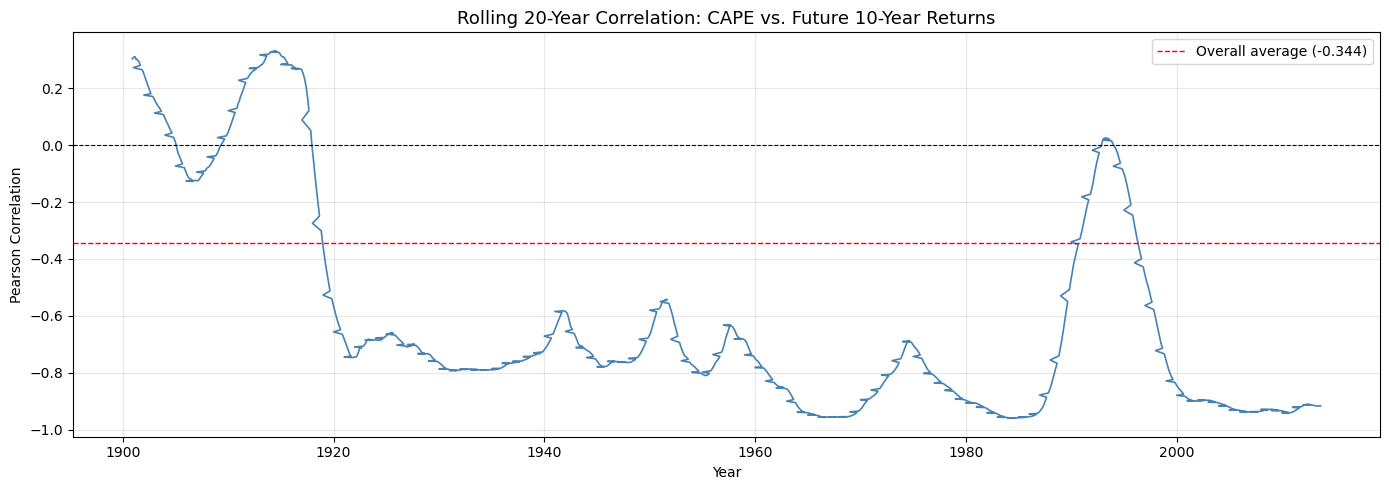

Chart saved: cape_rolling_correlation.png


In [22]:
# Calculate rolling 20-year correlation between CAPE and 10-year return
# 240 months = 20 years of data per window
df_model["rolling_corr"] = df_model["cape"].rolling(window=240).corr(df_model["return_10y"])

# Plot rolling correlation over time
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_model["date"], df_model["rolling_corr"], color="steelblue", linewidth=1.2)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axhline(-0.344, color="red", linewidth=1, linestyle="--", label="Overall average (-0.344)")

ax.set_title("Rolling 20-Year Correlation: CAPE vs. Future 10-Year Returns", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Pearson Correlation")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save chart
plt.savefig("cape_rolling_correlation.png", dpi=150)
plt.show()

print("Chart saved: cape_rolling_correlation.png")

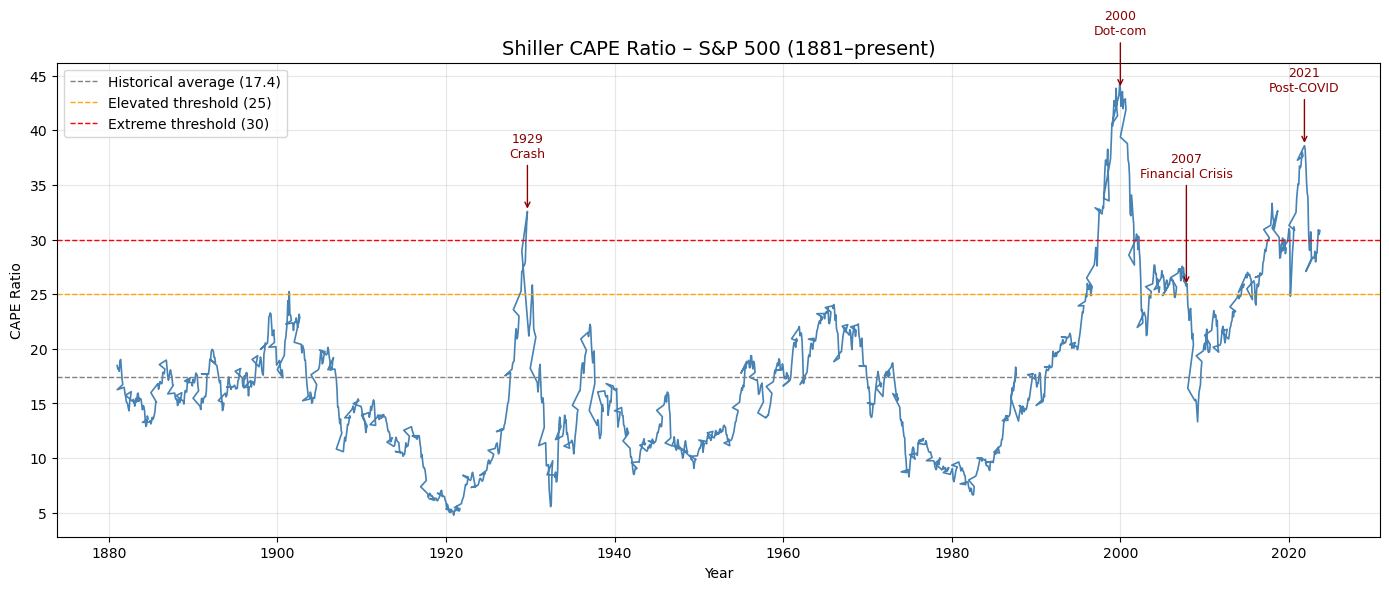

Chart saved: cape_over_time_annotated.png


In [26]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df["date"], df["cape"], color="steelblue", linewidth=1.2)

# Add horizontal lines for historical average and key thresholds
ax.axhline(df["cape"].mean(), color="gray", linestyle="--", linewidth=1, label=f"Historical average ({df['cape'].mean():.1f})")
ax.axhline(25, color="orange", linestyle="--", linewidth=1, label="Elevated threshold (25)")
ax.axhline(30, color="red", linestyle="--", linewidth=1, label="Extreme threshold (30)")

# Mark key historical bubble periods
bubbles = {
    "1929\nCrash": ("1929-09-01", 5),
    "2000\nDot-com": ("2000-01-01", 5),
    "2007\nFinancial Crisis": ("2007-11-01", 10),
    "2021\nPost-COVID": ("2021-11-01", 5)
}

for label, (date, offset) in bubbles.items():
    x = pd.Timestamp(date)
    y = df.loc[df["date"] == x, "cape"].values
    if len(y) > 0:
        ax.annotate(label, xy=(x, y[0]), xytext=(x, y[0] + offset),
                    ha="center", fontsize=9, color="darkred",
                    arrowprops=dict(arrowstyle="->", color="darkred"))

# Labels and formatting
ax.set_title("Shiller CAPE Ratio – S&P 500 (1881–present)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("CAPE Ratio")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save chart
plt.savefig("cape_over_time_annotated.png", dpi=150)
plt.show()

print("Chart saved: cape_over_time_annotated.png")

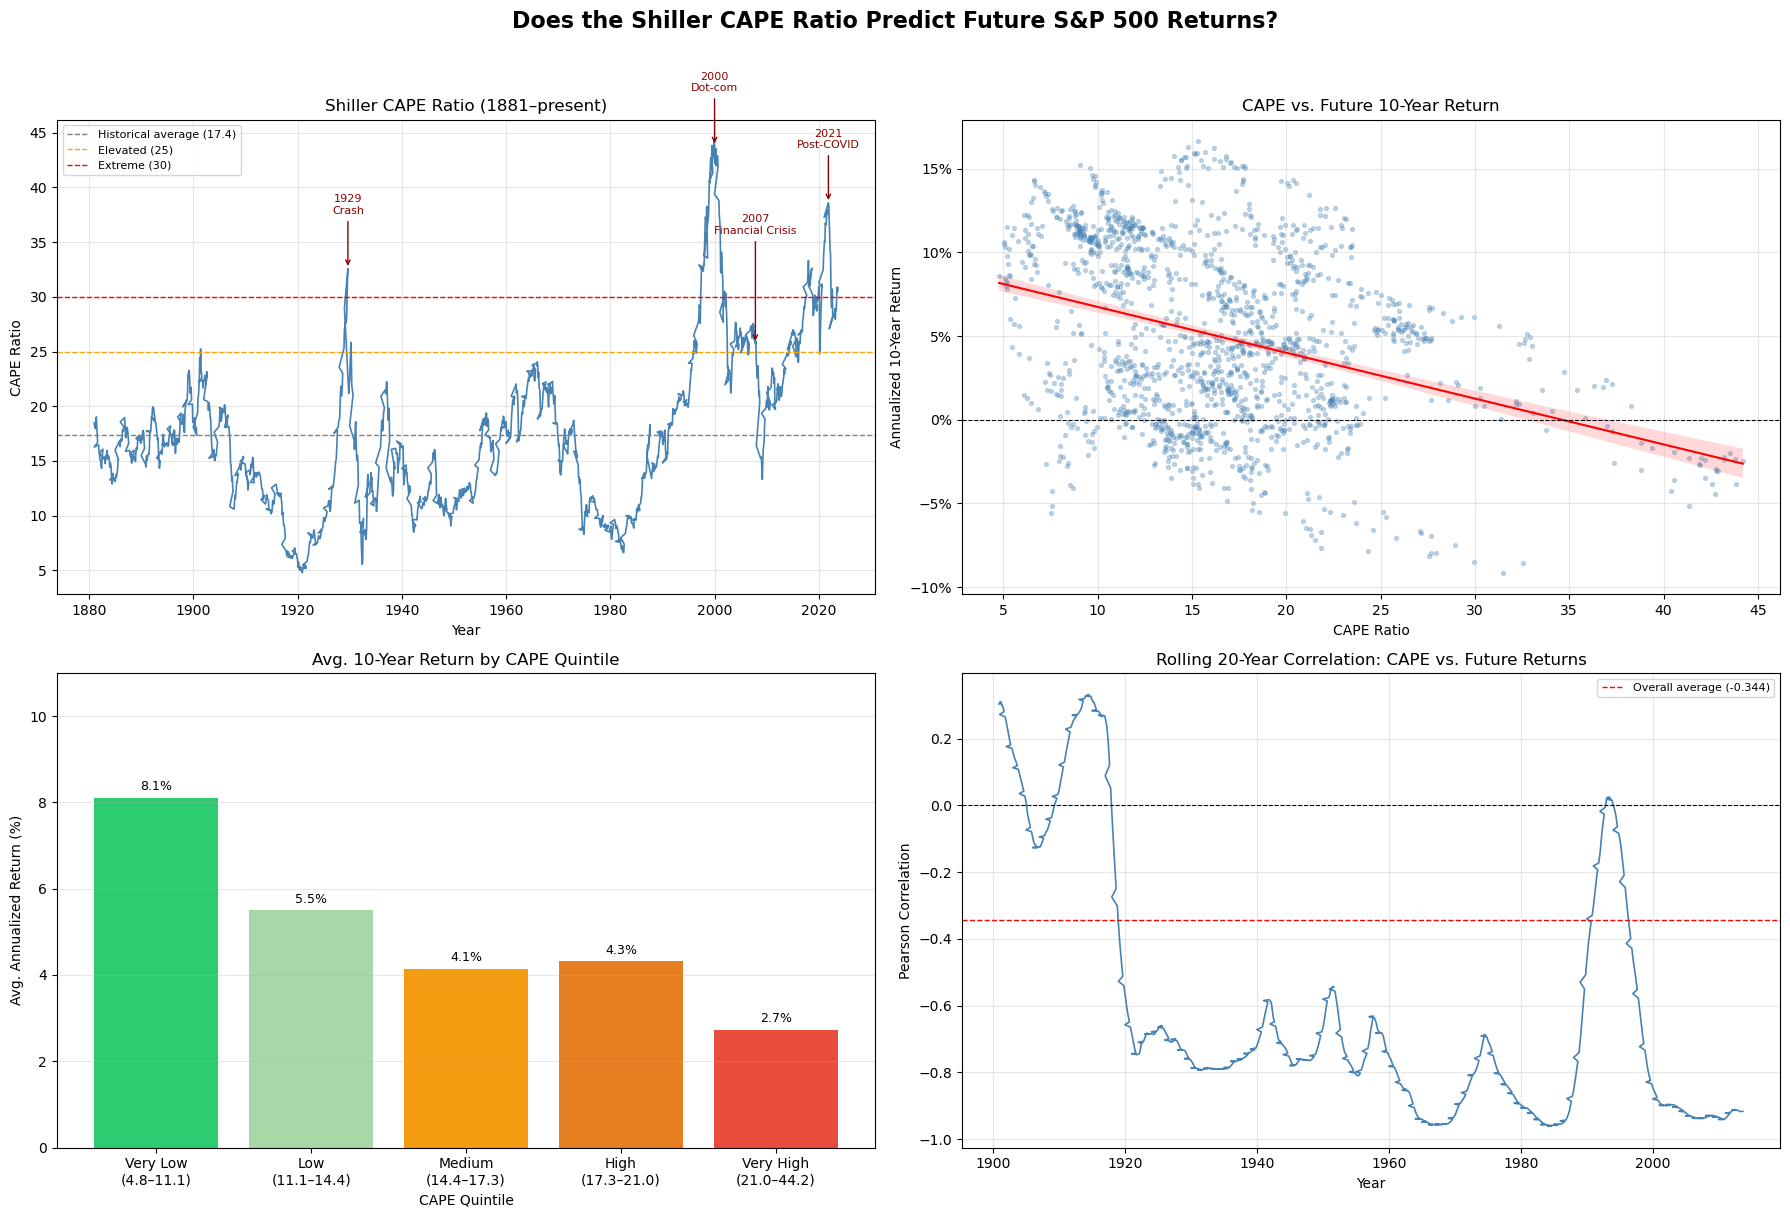

Chart saved: cape_dashboard.png


In [28]:
import seaborn as sns
import matplotlib.ticker as ticker
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- Chart 1: CAPE over time with annotations ---
ax1 = axes[0, 0]
ax1.plot(df["date"], df["cape"], color="steelblue", linewidth=1.2)
ax1.axhline(df["cape"].mean(), color="gray", linestyle="--", linewidth=1, label=f"Historical average ({df['cape'].mean():.1f})")
ax1.axhline(25, color="orange", linestyle="--", linewidth=1, label="Elevated (25)")
ax1.axhline(30, color="red", linestyle="--", linewidth=1, label="Extreme (30)")

bubbles = {
    "1929\nCrash": ("1929-09-01", 5),
    "2000\nDot-com": ("2000-01-01", 5),
    "2007\nFinancial Crisis": ("2007-11-01", 10),
    "2021\nPost-COVID": ("2021-11-01", 5)
}
for label, (date, offset) in bubbles.items():
    x = pd.Timestamp(date)
    y = df.loc[df["date"] == x, "cape"].values
    if len(y) > 0:
        ax1.annotate(label, xy=(x, y[0]), xytext=(x, y[0] + offset),
                     ha="center", fontsize=8, color="darkred",
                     arrowprops=dict(arrowstyle="->", color="darkred"))

ax1.set_title("Shiller CAPE Ratio (1881–present)", fontsize=12)
ax1.set_xlabel("Year")
ax1.set_ylabel("CAPE Ratio")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# --- Chart 2: CAPE vs future 10-year return scatter ---
ax2 = axes[0, 1]
ax2.scatter(df_model["cape"], df_model["return_10y"], alpha=0.3, s=8, color="steelblue")
sns.regplot(data=df_model, x="cape", y="return_10y", scatter=False,
            color="red", line_kws={"linewidth": 1.5}, ax=ax2)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title("CAPE vs. Future 10-Year Return", fontsize=12)
ax2.set_xlabel("CAPE Ratio")
ax2.set_ylabel("Annualized 10-Year Return")
ax2.grid(True, alpha=0.3)

# --- Chart 3: Quintile bar chart ---
ax3 = axes[1, 0]
quintile_labels = [
    "Very Low\n(4.8–11.1)",
    "Low\n(11.1–14.4)",
    "Medium\n(14.4–17.3)",
    "High\n(17.3–21.0)",
    "Very High\n(21.0–44.2)"
]
bars = ax3.bar(quintile_labels, quintile_summary["avg_return_pct"],
               color=["#2ecc71", "#a8d8a8", "#f39c12", "#e67e22", "#e74c3c"])
for bar, val in zip(bars, quintile_summary["avg_return_pct"]):
    ax3.text(bar.get_x() + bar.get_width() / 2, val + 0.1,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=9)
ax3.set_title("Avg. 10-Year Return by CAPE Quintile", fontsize=12)
ax3.set_xlabel("CAPE Quintile")
ax3.set_ylabel("Avg. Annualized Return (%)")
ax3.set_ylim(0, 11)
ax3.grid(True, axis="y", alpha=0.3)

# --- Chart 4: Rolling correlation ---
ax4 = axes[1, 1]
ax4.plot(df_model["date"], df_model["rolling_corr"], color="steelblue", linewidth=1.2)
ax4.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax4.axhline(-0.344, color="red", linewidth=1, linestyle="--", label="Overall average (-0.344)")
ax4.set_title("Rolling 20-Year Correlation: CAPE vs. Future Returns", fontsize=12)
ax4.set_xlabel("Year")
ax4.set_ylabel("Pearson Correlation")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# Overall title
fig.suptitle("Does the Shiller CAPE Ratio Predict Future S&P 500 Returns?", fontsize=16, fontweight="bold", y=1.01)

plt.tight_layout()

# Save dashboard
plt.savefig("cape_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved: cape_dashboard.png")

File saved: cape_regression_results.csv
